### Lipschitz constant

Given a function $f(x)$ and an interval $x \in [a,b]$, the Lipschitz constant $L$ is the smallest positive real number such that:

$$
    |f(x_2)-f(x_1)| \le L |x_2-x_1| \qquad \forall \, x_1, x_2 \in [a,b]
$$

Equivalently, $L$ can be defined as:

$$
    L = \sup_{x_1 \ne x_2} \left| \frac{f(x_2) - f(x_1)}{x_2 - x_1} \right|
$$

If the derivative $f'(x)$ exists and is continuous on $[a, b]$:

$$
    L = \max_{x \in [a,b]} |f'(x)|
$$

A function is Lipschitz if such a finite constant $L$ exists. If $L < 1$, then $f(x)$ is a contraction, and hence also Lipschitz.

We're going to compute $L$ for a given function and interval using a derivative-free Monte Carlo approach.

In [1]:
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

In [2]:
def L_montecarlo(f, a, b, N): # Monte Carlo approach for computing L

    x = np.random.uniform(a, b, size = (N, 2)) # Sample N couples uniformly in [a, b] ||| First column: x_1, second column: x_2. A row is a couple (x_1, x_2)
    dx = np.abs(x[:, 1] - x[:, 0]) # Compute the denominator for each couple

    mask = (dx > 1e-12) # Ignore couples with x1 approx x2 (denominator almost zero)
    if not np.any(mask):
        return 0.0

    x1 = x[mask, 0]
    x2 = x[mask, 1]
    dx = dx[mask]

    # Evaluate f at the valid points
    f1 = f(x1)
    f2 = f(x2)

    L_couples = np.abs(f2 - f1) / dx # Compute the Lipschitz ratio for each couple
    
    return np.max(L_couples) # Return the maximum value found


def plot_L(f, a, b, M, N):  # Plot function and stats

    global L_montecarlo

    FS = 8  # shared font size for legend and text box

    L_values = np.array([L_montecarlo(f, a, b, N) for _ in range(M)]) # Array of L values

    mean_L = np.mean(L_values) # Best value of L
    std_L = np.std(L_values) # Standard deviation

    error_L = 2.0 * std_L # Error estimated as twice the standard deviation
    lower, upper = mean_L - error_L, mean_L + error_L

    prob = 100.0 * np.mean((L_values >= lower) & (L_values <= upper)) # Probability [%] to find the real value L in [mean - error, mean + error]

    ## Plot section ##
    
    plt.hist(L_values, bins = 'auto', edgecolor = 'black', alpha = 0.75)

    plt.axvline(mean_L, color = 'red', linestyle = '--', linewidth = 1.5, label = 'Mean')
    plt.axvline(mean_L + std_L, color = 'green', linestyle = '--', linewidth = 1.5, label = 'Std')
    plt.axvline(mean_L - std_L, color = 'green', linestyle = '--', linewidth = 1.5)

    plt.xlabel('Estimated Lipschitz constant L')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {M} Monte Carlo estimates of L (N = {N})')

    plt.legend(loc = 'best', fontsize = FS)
    plt.grid('--', alpha = 0.25)

    plt.tight_layout(rect = [0, 0, 0.80, 1])

    ax = plt.gca()

    textstr = (f'Mean  = {mean_L:.6f}\n'
               f'Std   = {std_L:.6f}\n'
               f'Error = {error_L:.0g}\n' # Only the first significant digit matters when dealing with errors
               f'Prob  = {prob:.2f}%')

    ax.text(
        1.02, 1.0,
        textstr,
        transform = ax.transAxes,
        fontsize = FS,
        verticalalignment = 'top',
        horizontalalignment = 'left',
        clip_on = False,
        bbox = {
            'boxstyle': 'round',
            'facecolor': 'white',
            'edgecolor': 'none',
            'linewidth': 0,
            'alpha': 0.8
        },
    )

    plt.show()


def L_scipy(f, a, b): # Method to find L using SciPy capabilities

    def objective(x, f): # Target function: - | (f(x_2) - f(x_1)) / (x_2 - x_1) |
        x1, x2 = x[0], x[1]
        diff = np.abs(x2 - x1)
        return - np.abs(f(x2) - f(x1)) / diff if (diff > 1e-12) else 0.0

    result = differential_evolution( # Use global optimization
        func = objective,
        bounds = [(a, b), (a, b)],
        args = (f,)
    )

    return -result.fun # L

Let's compute $L$ for:

$$
    f(x) = \left| x ^2 - 4 x + 3  \right| + 2 x \qquad x \in [0, 4]
$$

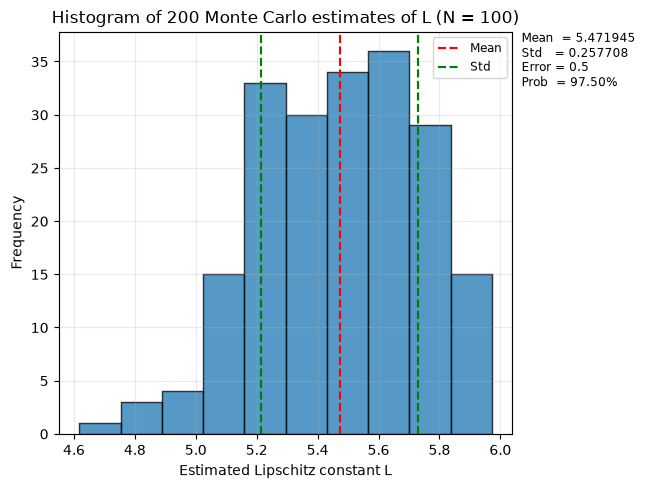

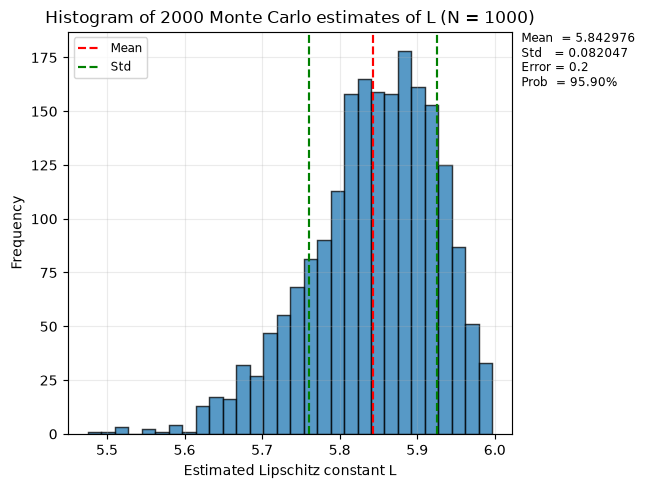

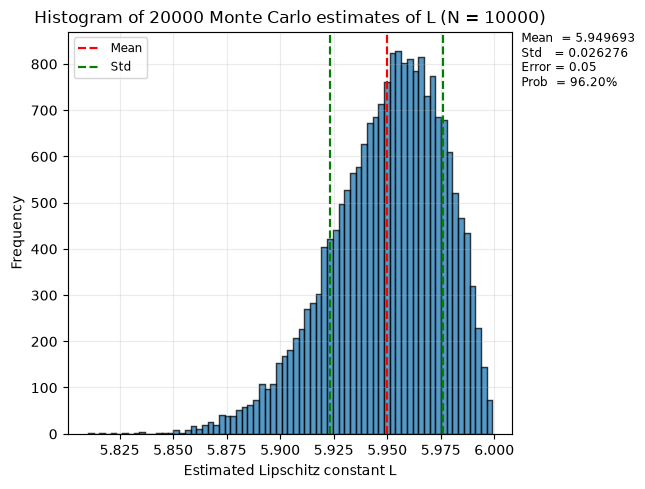

In [3]:
f = lambda x: np.abs(x ** 2 - 4.0 * x + 3.0) + 2.0 * x
a = 0.0
b = 4.0

# Results
plot_L(f, a, b, M = 200, N = 100)
plot_L(f, a, b, M = 2_000, N = 1_000)
plot_L(f, a, b, M = 20_000, N = 10_000)

Our best result is:

$$
    L = 5.95 \pm 0.05
$$

In [4]:
L_scipy(f, a, b)

np.float64(5.999998377998841)

Let's compute $L$ for:

$$
    f(x) = \ln \left( 1 + \frac{1}{\sqrt{x}} \right) \qquad x \in [1, 3]
$$

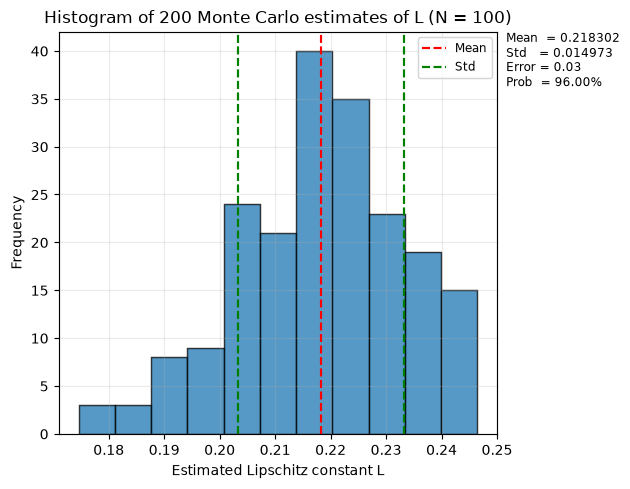

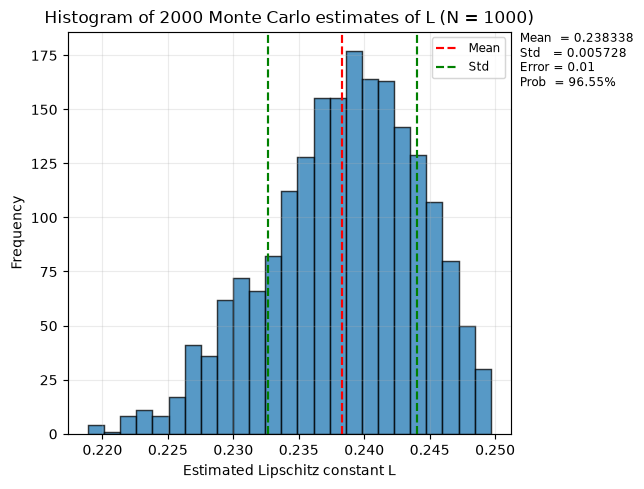

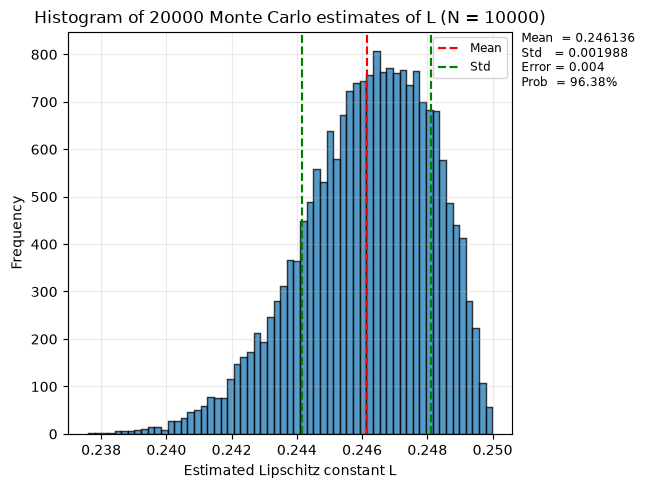

In [5]:
f = lambda x: np.log(1.0 + (1.0 / np.sqrt(x)))
a = 1.0
b = 3.0

# Results
plot_L(f, a, b, M = 200, N = 100)
plot_L(f, a, b, M = 2_000, N = 1_000)
plot_L(f, a, b, M = 20_000, N = 10_000)

Our best result:

$$
    L = 0.246 \pm 0.004
$$

In [6]:
L_scipy(f, a, b)

np.float64(0.2499985915687141)

Let's compute $L$ for:

$$
    f(x) = x \, \sin \left( \frac{1}{x} \right) \qquad x \in [-1, 1]
$$

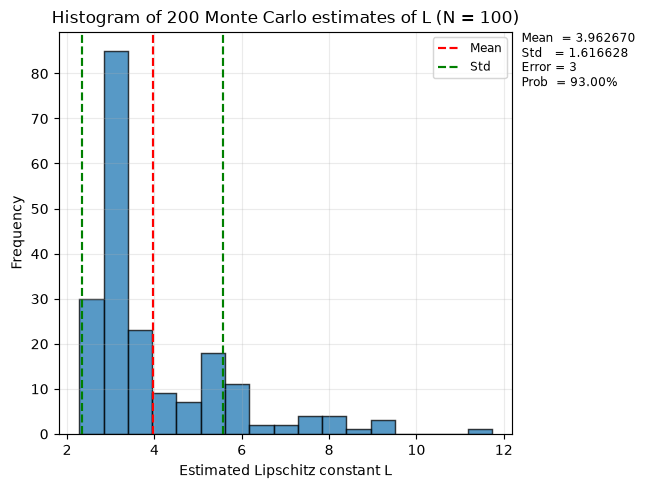

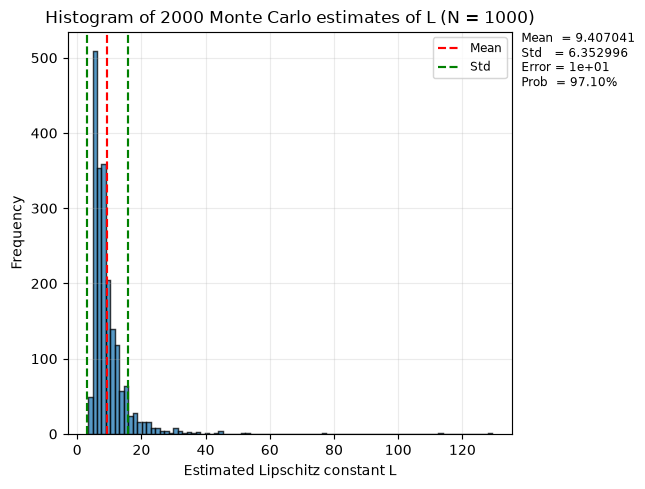

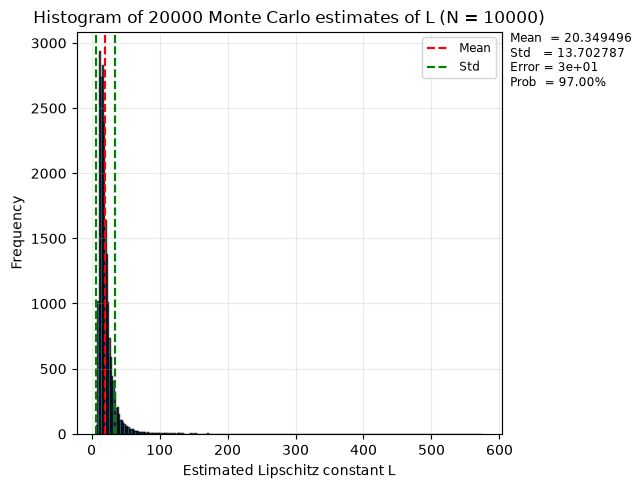

In [7]:
f = lambda x: np.where(np.abs(x) < 1e-12, 0.0, x * np.sin(1.0 / x))

a = -1.0
b = 1.0

# Results
plot_L(f, a, b, M = 200, N = 100)
plot_L(f, a, b, M = 2_000, N = 1_000)
plot_L(f, a, b, M = 20_000, N = 10_000)

In [8]:
L_scipy(f, a, b)

np.float64(1199805.5675025906)

This function is not Lipschitz